# MF34 Multigroup Collapse: Fe-56 (JEFF-4.0)

This notebook applies the MF34-to-multigroup grouping to the JEFF-4.0 Fe-56 evaluation
using the SCALE 56-group energy structure. It produces two comparison figures:

1. **Grouped vs. original** first Legendre coefficient ($a_1$)
2. **Multigroup uncertainty vs. original uncertainty** for $a_1$

In [1]:
from kika.endf.read_endf import read_endf
from kika.cov.multigroup import MF34_to_MG
from kika.energy_grids import SCALE56
from kika.plotting import PlotBuilder, PlotData, UncertaintyBand
from kika.plotting.multigroup_covariance import (
    endf_uncertainty_band,
    endf_uncertainty_step_data,
)

endf_path = '/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt'
endf = read_endf(endf_path)
print(f'Available MF sections: {list(endf.mf.keys())}')
print(f'MF4  MT reactions: {list(endf.mf[4].mt.keys())}')
print(f'MF34 MT reactions: {list(endf.mf[34].mt.keys())}')

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


Available MF sections: [1, 4, 34]
MF4  MT reactions: [2, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818]
MF34 MT reactions: [2]


In [2]:
# Determine isotope ZAID from the MF34 covariance data
mf34_cov = endf.mf[34].mt[2].to_ang_covmat()
zaid = mf34_cov.isotopes[0]
print(f'Isotope ZAID: {zaid}')
print(f'Available Legendre orders: {sorted(set(mf34_cov.l_rows))}')

Isotope ZAID: 26056
Available Legendre orders: [1, 2, 3, 4, 5, 6]


In [3]:
# Multigroup collapse using SCALE 56-group structure
SCALE56_eV = [e * 1e6 for e in SCALE56]  # MeV -> eV

mg_cov = MF34_to_MG(
    endf_object=endf,
    energy_grid=SCALE56_eV,
    weighting_function='lethargy',
    isotope=zaid,
    mt=2
)
print(mg_cov)

Multigroup MF34 Angular Covariance Matrix Data:
- 21 matrices
- 56 energy groups
- 1 unique isotopes
- 1 unique reaction types
- 6 unique Legendre indices
- Weighting: lethargy
- Normalization: mf34_cell


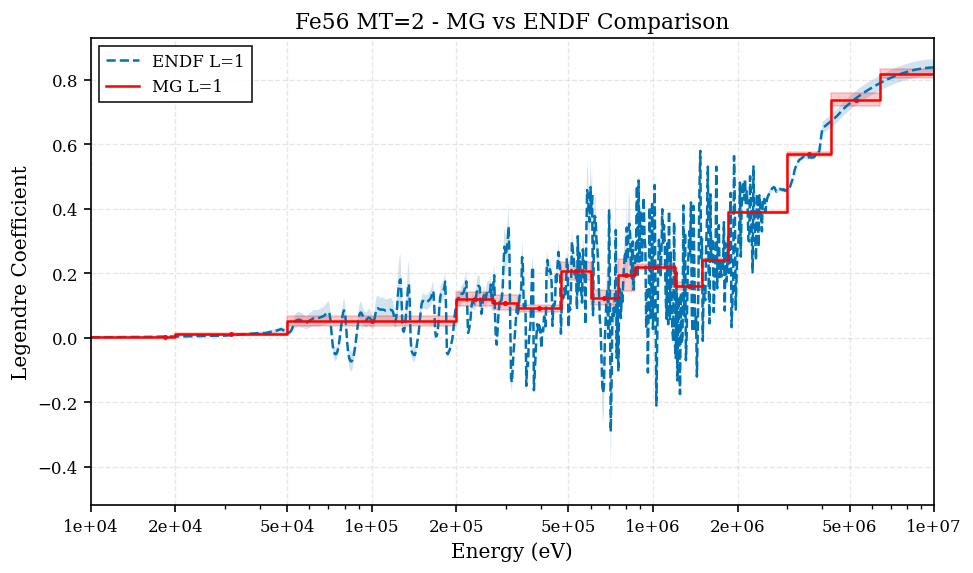

In [4]:
import numpy as np

# Figure 1: Grouped vs original first Legendre coefficient (a_1)
mf4_mt = endf.mf[4].mt[2]
mf34_cov = endf.mf[34].mt[2].to_ang_covmat()

# --- Styling knobs (tweak these) ---
MG_COLOR = "red"
MG_LINEWIDTH = 1.5
MG_LINESTYLE = "-"
MG_LABEL = "MG L=1"

ENDF_COLOR = None       # None → use palette default
ENDF_LINEWIDTH = 1.5
ENDF_LINESTYLE = "--"
ENDF_LABEL = "ENDF L=1"
# ------------------------------------

ENERGY_RANGE = (1e4, 1e7)

# Get ENDF dense curve
endf_data = mf4_mt.to_dense_plot_data(
    order=1,
    energy_range=ENERGY_RANGE,
    label=ENDF_LABEL,
    linestyle=ENDF_LINESTYLE,
    linewidth=ENDF_LINEWIDTH,
    color=ENDF_COLOR,
)
endf_band = endf_uncertainty_band(
    mf34_cov, mf4_mt, zaid, 2, 1,
    sigma=1.0,
    nominal_data=endf_data,
)

# Get MG step data
mg_data, mg_band = mg_cov.to_plot_data(
    nuclide=zaid, mt=2, order=1, sigma=1.0,
    label=MG_LABEL,
    color=MG_COLOR,
    linewidth=MG_LINEWIDTH,
    linestyle=MG_LINESTYLE,
)

# MG scatter markers at bin centres
mg_edges = np.asarray(mg_cov.energy_grid, dtype=float)
mg_centers = np.sqrt(mg_edges[:-1] * mg_edges[1:])
mg_scatter = PlotData(
    x=mg_centers,
    y=mg_data.y[:-1],
    plot_type="scatter",
    marker="o",
    markersize=4,
    color=MG_COLOR,
    label=None,
)

# Build
fig1 = (
    PlotBuilder(figsize=(12, 7), dpi=300)
    .add_data(endf_data, uncertainty=endf_band)   # background
    .add_data(mg_data, uncertainty=mg_band)        # foreground
    .add_data(mg_scatter)
    .set_scales(log_x=True)
    .set_limits(x_lim=ENERGY_RANGE)
    .set_labels(
        x_label="Energy (eV)",
        y_label="Legendre Coefficient",
        title="Fe56 MT=2 - MG vs ENDF Comparison",
    )
    .set_legend(loc="best")
    .build()
)
fig1.savefig('/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/fe56_mg_vs_endf_a1.png', dpi=300, bbox_inches='tight')

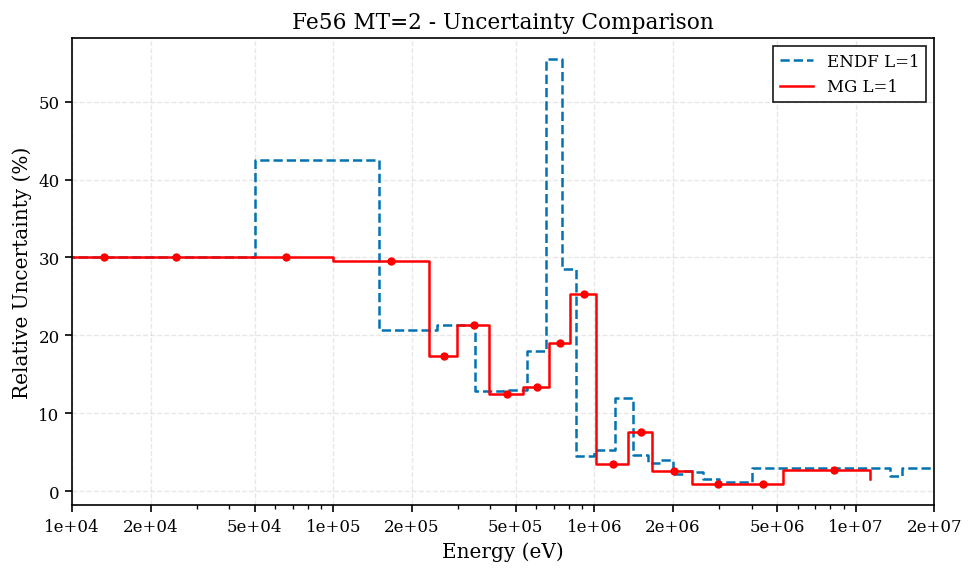

In [5]:
# Figure 2: Multigroup uncertainty vs original uncertainty for a_1

# --- Styling knobs (tweak these) ---
MG_UNC_COLOR = "red"
MG_UNC_LINEWIDTH = 1.5
MG_UNC_LINESTYLE = "-"
MG_UNC_LABEL = "MG L=1"

ENDF_UNC_COLOR = None       # None → use palette default
ENDF_UNC_LINEWIDTH = 1.5
ENDF_UNC_LINESTYLE = "--"
ENDF_UNC_LABEL = "ENDF L=1"
# ------------------------------------

ENERGY_RANGE_UNC = (1e4, 2e7)

# Get ENDF uncertainty step data
endf_unc = endf_uncertainty_step_data(
    mf34_cov, mf4_mt, zaid, 2, 1,
    sigma=1.0,
    label=ENDF_UNC_LABEL,
    linestyle=ENDF_UNC_LINESTYLE,
    linewidth=ENDF_UNC_LINEWIDTH,
    color=ENDF_UNC_COLOR,
)

# Get MG uncertainty step data
mg_unc = mg_cov._create_uncertainty_plotdata(
    isotope=zaid, mt=2, order=1, sigma=1.0,
    use_centers=True,
    as_percentage=True,
    label=MG_UNC_LABEL,
)
if mg_unc is not None:
    mg_unc.color = MG_UNC_COLOR
    mg_unc.linewidth = MG_UNC_LINEWIDTH
    mg_unc.linestyle = MG_UNC_LINESTYLE
    mg_unc.plot_type = "step"
    mg_unc.marker = "o"
    mg_unc.markersize = 4

# Build
builder = PlotBuilder(figsize=(12, 7), dpi=300)
if endf_unc is not None:
    builder.add_data(endf_unc)        # background
if mg_unc is not None:
    builder.add_data(mg_unc)          # foreground

fig2 = (
    builder
    .set_scales(log_x=True)
    .set_limits(x_lim=ENERGY_RANGE_UNC)
    .set_labels(
        x_label="Energy (eV)",
        y_label="Relative Uncertainty (%)",
        title="Fe56 MT=2 - Uncertainty Comparison",
    )
    .set_legend(loc="best")
    .build()
)
fig2.savefig('/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/fe56_mg_vs_endf_unc_a1.png', dpi=300, bbox_inches='tight')